In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [48]:
df = pd.read_csv('nasa_temps.csv',skiprows=8)
df.head()

,time,mean_M2TMNXSLV_5_12_4_T2M
0,2020-01-01 00:00:00,282.196045
1,2020-02-01 00:00:00,282.277618
2,2020-03-01 00:00:00,286.146698
3,2020-04-01 00:00:00,287.838745
4,2020-05-01 00:00:00,291.594086


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   time                        69 non-null     object 
 1    mean_M2TMNXSLV_5_12_4_T2M  69 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.2+ KB


In [50]:
df = df.rename(columns={df.columns[0]:'date',
                        df.columns[1]:'temps Celsius'})
df['date'] = pd.to_datetime(df['date'])
df['temps Celsius']= df['temps Celsius'] - 273.15
df['ordinal date'] = df['date'].map(pd.Timestamp.toordinal)
df.head()

,date,temps Celsius,ordinal date
0,2020-01-01,9.046045,737425
1,2020-02-01,9.127618,737456
2,2020-03-01,12.996698,737485
3,2020-04-01,14.688745,737516
4,2020-05-01,18.444086,737546


In [51]:
X = df['ordinal date'] 
y = df['temps Celsius']
train_size =int(len(df)*0.8)
X_train= df[['ordinal date']].iloc[:train_size]
X_test= df[['ordinal date']].iloc[train_size:]
y_train= df['temps Celsius'].iloc[:train_size]
y_test = df['temps Celsius'].iloc[train_size:]
model = LinearRegression().fit(X_train,y_train)
predictions = model.predict(X_test)
daily_slope = model.coef_[0]
annual_warming_rate = daily_slope *365
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test,predictions)
print(f"""Analysis
Elizabeth City Annual Warming Rate: {annual_warming_rate:.2f} degrees Celsius
Mean absolute error: {mae}
R2 Score:{r2}
""")

Analysis
Elizabeth City Annual Warming Rate: 0.39 degrees Celsius
Mean absolute error: 6.661924548317943
R2 Score:0.010469789682876596



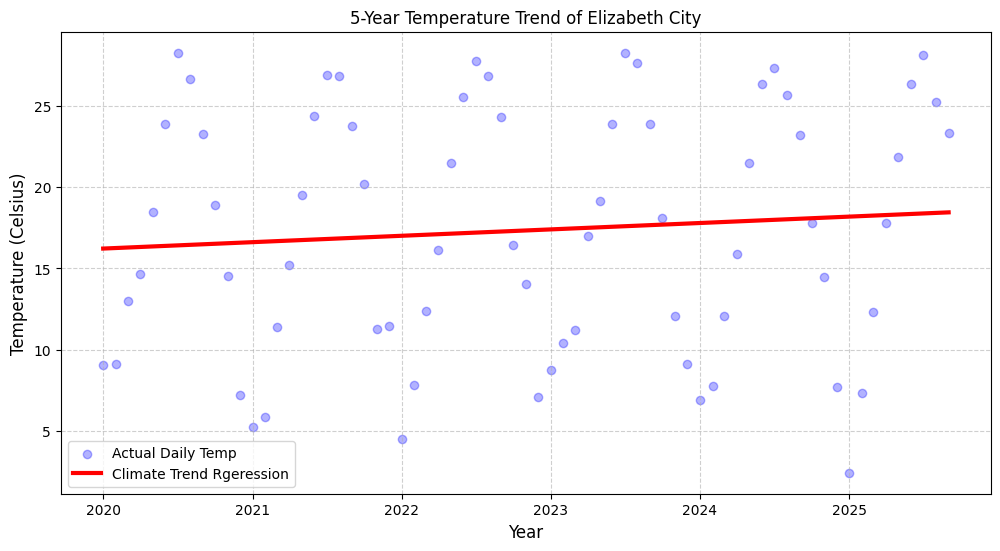

In [53]:
#Visualization
plt.figure(figsize=(12,6))
plt.scatter(df['date'],df['temps Celsius'], color='blue', alpha=0.3, label='Actual Daily Temp')
plt.plot(df['date'], model.predict(df[['ordinal date']]), color='red', linewidth = 3, label = 'Climate Trend Rgeression')
plt.title('5-Year Temperature Trend of Elizabeth City')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (Celsius)', fontsize = 12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()